# **0. 사용할 패키지 불러오기**

In [1]:
import os
import keras
import numpy as np
import tensorflow as tf
from keras import optimizers
from keras import callbacks
from keras.datasets import cifar10
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D

# **1. 데이터 불러오기**

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

170498071/170498071 [==============================] - 6s 0us/step
x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


# **2. 모델 정의**

In [3]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same',
                 input_shape=x_train.shape[1:]))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(10))
model.add(Activation('softmax'))

model.summary

<bound method Model.summary of <keras.src.engine.sequential.Sequential object at 0x7db558a6b250>>

# **3. 모델 학습과정 설정**

In [4]:
model.compile(loss='binary_crossentropy', optimizer=optimizers.SGD(lr=1e-3, momentum=0.9), metrics=['accuracy'])

# **4. 학습하기**

In [6]:
model.fit(x_train,y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), shuffle=True)

Epoch 1/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2699 - accuracy: 0.3315 - val_loss: 0.2501 - val_accuracy: 0.3892
Epoch 2/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2536 - accuracy: 0.3892 - val_loss: 0.2379 - val_accuracy: 0.4542
Epoch 3/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.2416 - accuracy: 0.4318 - val_loss: 0.2225 - val_accuracy: 0.4959
Epoch 4/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2317 - accuracy: 0.4612 - val_loss: 0.2197 - val_accuracy: 0.4968
Epoch 5/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2248 - accuracy: 0.4866 - val_loss: 0.2082 - val_accuracy: 0.5260
Epoch 6/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2194 - accuracy: 0.4974 - val_loss: 0.2089 - val_accuracy: 0.5336
Epoch 7/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.2130 - accuracy: 0.5173 - val_loss: 0.1989 - val_accuracy:

# **5. 모델 평가하기**

In [7]:
loss_and_metrics = model.evaluate(x_test, y_test, batch_size=32)
print('## evaluation loss and metrics ##')
print(loss_and_metrics)

313/313 [==============================] - 1s 2ms/step - loss: 0.1873 - accuracy: 0.5932
## evaluation loss and metrics ##
[0.18728458881378174, 0.5932000279426575]


In [8]:
import cv2
import matplotlib.pyplot as plt
import glob

1/1 [==============================] - 0s 17ms/step
## probability ##
[[7.0127432e-04 1.6585347e-05 3.5596993e-02 7.2738364e-02 4.3643060e-01
  1.6500047e-01 1.7561303e-02 2.7028862e-01 3.2270001e-04 1.3431199e-03]]
4
4


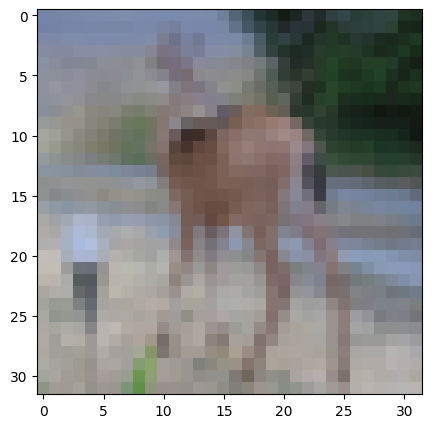

In [12]:
# 0:airplane, 1:automobile, 2:bird, 3:cat, 4:deer, 5:dog, 6:frog, 7:horse, 8:ship, 9:truck.
index = 100
xhat = x_test[index:index+1]
yhat = model.predict(xhat)
print('## probability ##')
print(yhat)
print(np.argmax(yhat))
print(np.argmax(y_test[index:index+1]))

plt.figure(figsize=(5, 5))
image = x_test[index]
plt.imshow(image, cmap='Greys')
plt.show()
